# CausalNex API Tutorial

This notebook explores the CausalNex library for causal inference using Bayesian Networks.
It demonstrates the complete workflow from structure learning to inference and causal interventions.

References:
- https://causalnex.readthedocs.io/
- https://causalnex.readthedocs.io/en/latest/03_tutorial/01_first_tutorial.html

In [38]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

# System libraries.
import logging

# Third-party libraries.
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Note: we need to import sklearn first to avoid conflicts with libgomp-d22c30c5.so.1.0.0: cannot allocate memory in static TLS block
import sklearn

_ = sklearn

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:
# import helpers.hmodule as hmodule
# hmodule.install_module_if_not_present(
#     [""],
#     use_activate=True,
#     use_sudo=False,
#     venv_path="/opt/venv",
# )

In [11]:
# Helpers packages.

# Tutorial-specific packages.
import tutorials.causalnex.causalnex_utils as tcnut
import causalnex

print(causalnex.__version__)

_LOG = logging.getLogger(__name__)
tcnut.init_loggers(_LOG)

_LOG.info("Test _LOG.info")

0.12.1
Test _LOG.info


## Cell 1: Load Data

In [12]:
# Load the student performance dataset from https://archive.ics.uci.edu/dataset/320/student+performance
df = tcnut.load_student_performance_data(data_dir="data")
_LOG.info("Dataset shape: %s", df.shape)
display(df.head())

File already exists at '/git_root/tutorials/causalnex/data/student_performance.zip', skipping download
Loading student performance data from '/git_root/tutorials/causalnex/data/student_performance/student-mat.csv'
Data loaded: 395 rows, 33 columns
Dataset shape: (395, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,3,yes,no,yes,no,yes,yes,yes,no,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,yes,yes,yes,yes,yes,yes,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,yes,no,yes,yes,no,no,4,3,2,1,2,5,4,6,10,10


In [22]:
print(df.columns)

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3'], dtype='object')


In [26]:
!cat /git_root/tutorials/causalnex/data/info.txt 

- This data approach student achievement in secondary education of two Portuguese
  schools

- The data attributes include student grades, demographic, social and school
  related features) and it was collected by using school reports and
  questionnaires

- Two datasets are provided regarding the performance in two distinct subjects:
  Mathematics (mat) and Portuguese language (por). In [Cortez and Silva, 2008],
  the two datasets were modeled under binary/five-level classification and
  regression tasks.

- Important note: the target attribute G3 has a strong correlation with
  attributes G2 and G1. This occurs because G3 is the final year grade (issued at
  the 3rd period), while G1 and G2 correspond to the 1st and 2nd period grades.
  It is more difficult to predict G3 without G2 and G1, but such prediction is
  much more useful 


In [25]:
!cat /git_root/tutorials/causalnex/data/student.txt

# Attributes for both student-mat.csv (Math course) and student-por.csv (Portuguese language course) datasets:
1 school - student's school (binary: "GP" - Gabriel Pereira or "MS" - Mousinho da Silveira)
2 sex - student's sex (binary: "F" - female or "M" - male)
3 age - student's age (numeric: from 15 to 22)
4 address - student's home address type (binary: "U" - urban or "R" - rural)
5 famsize - family size (binary: "LE3" - less or equal to 3 or "GT3" - greater than 3)
6 Pstatus - parent's cohabitation status (binary: "T" - living together or "A" - apart)
7 Medu - mother's education (numeric: 0 - none,  1 - primary education (4th grade), 2 – 5th to 9th grade, 3 – secondary education or 4 – higher education)
8 Fedu - father's education (numeric: 0 - none,  1 - primary education (4th grade), 2 – 5th to 9th grade, 3 – secondary education or 4 – higher education)
9 Mjob - mother's job (nominal: "teacher", "health" care related, civil "services" (e.g. administrative or police), "at_home" or 

In [30]:
metadata_df = pd.read_csv("/git_root/tutorials/causalnex/data/metadata.csv")
display(metadata_df)

,Variable Name,Role,Type,Demographic,Description,Units,Missing Values
0,school,Feature,Categorical,NaN,student's school (binary: 'GP' - Gabriel Perei...,NaN,no
1,sex,Feature,Binary,Sex,student's sex (binary: 'F' - female or 'M' - m...,NaN,no
2,age,Feature,Integer,Age,student's age (numeric: from 15 to 22),NaN,no
3,address,Feature,Categorical,NaN,student's home address type (binary: 'U' - urb...,NaN,no
4,famsize,Feature,Categorical,Other,family size (binary: 'LE3' - less or equal to ...,NaN,no
5,Pstatus,Feature,Categorical,Other,parent's cohabitation status (binary: 'T' - li...,NaN,no
6,Medu,Feature,Integer,Education Level,"mother's education (numeric: 0 - none, 1 - pri...",NaN,no
7,Fedu,Feature,Integer,Education Level,"father's education (numeric: 0 - none, 1 - pri...",NaN,no
8,Mjob,Feature,Categorical,Occupation,"mother's job (nominal: 'teacher', 'health' car...",NaN,no
9,Fjob,Feature,Categorical,Occupation,"father's job (nominal: 'teacher', 'health' car...",NaN,no


## Cell 2: Structure Learning

Define the causal structure of the Bayesian Network by specifying relationships between variables.

- Manual definition via domain expertise
- Algorithmic learning using NOTEARS algorithm
- Hybrid approach combining both methods

In [13]:
from causalnex.structure import StructureModel

# Create a StructureModel instance to define causal relationships.
sm = StructureModel()
# Add edges representing causal relationships between variables.
sm.add_edges_from(
    [
        ("health", "absences"),
        ("health", "G1"),
        ("studytime", "G1"),
        ("studytime", "G2"),
        ("G1", "G2"),
        ("absences", "G1"),
        ("absences", "G2"),
    ]
)
print(f"Nodes: {list(sm.nodes)}")
print(f"Edges: {list(sm.edges)}")

Structure nodes: ['health', 'absences', 'G1', 'studytime', 'G2']
Structure edges: [('health', 'absences'), ('health', 'G1'), ('absences', 'G1'), ('absences', 'G2'), ('G1', 'G2'), ('studytime', 'G1'), ('studytime', 'G2')]
Nodes: ['health', 'absences', 'G1', 'studytime', 'G2']
Edges: [('health', 'absences'), ('health', 'G1'), ('absences', 'G1'), ('absences', 'G2'), ('G1', 'G2'), ('studytime', 'G1'), ('studytime', 'G2')]


In [32]:
# Plot the relationships using networkx.
if False:
    from causalnex.plots import plot_structure, NODE_STYLE, EDGE_STYLE
    
    viz = plot_structure(
        sm,
        all_node_attributes=NODE_STYLE.WEAK,
        all_edge_attributes=EDGE_STYLE.WEAK,
    )
    # viz.save_graph("graph.html")
    # display(HTML("graph.html"))

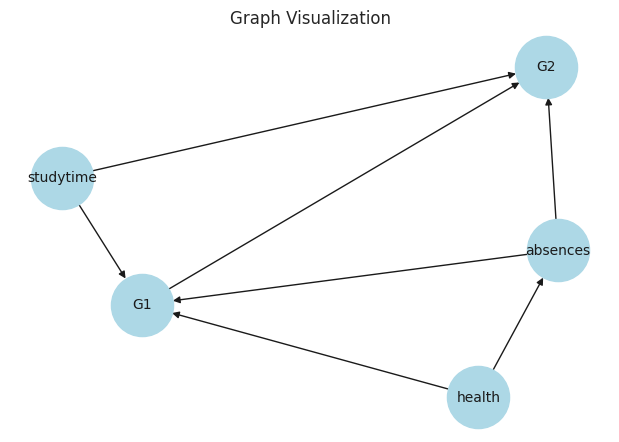

In [41]:
# Plot the relationships using networkx.
G = nx.DiGraph(sm)
plt.figure(figsize=(6, 4))

pos = nx.spring_layout(G, seed=42)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_color="lightblue",
    node_size=2000,
    font_size=10,
    arrows=True,
)

plt.title("Graph Visualization")

plt.show()

In [43]:
# Plot using pygraphviz.
# from networkx.drawing.nx_pydot import graphviz_layout
# import matplotlib.pyplot as plt
# pos = graphviz_layout(G, prog="dot")
# nx.draw(
#     G,
#     pos,
#     with_labels=True,
#     node_color="lightgreen",
#     node_size=2000,
#     arrows=True,
# )
# plt.show()

## Cell 3: Data Discretization

Convert continuous features into categorical buckets with meaningful labels.
Bayesian Networks require discrete distributions for probability estimation.

In [44]:
# Create a copy of the dataframe for discretization.
df_discrete = df.copy()

# Discretize continuous variables into categorical buckets.
# Replace originals so column names match the structure model nodes.
df_discrete["studytime"] = pd.cut(
    df["studytime"],
    bins=[0, 1, 2, 3, 4],
    labels=["very_low", "low", "medium", "high"],
).astype(str)
df_discrete["absences"] = pd.cut(
    df["absences"],
    bins=[-1, 5, 10, 20, 100],
    labels=["low", "medium", "high", "very_high"],
).astype(str)
df_discrete["G1"] = pd.cut(
    df["G1"], bins=[-1, 10, 20], labels=["fail", "pass"]
).astype(str)
df_discrete["G2"] = pd.cut(
    df["G2"], bins=[-1, 10, 20], labels=["fail", "pass"]
).astype(str)
df_discrete["health"] = df["health"].astype(str)
_LOG.info("Discretized data shape: %s", df_discrete.shape)

display(df_discrete[["health", "studytime", "absences", "G1", "G2"]].head())

Discretized data shape: (395, 33)


,health,studytime,absences,G1,G2
0,3,low,medium,fail,fail
1,3,low,low,fail,fail
2,3,low,medium,fail,fail
3,5,medium,low,pass,pass
4,5,low,low,fail,fail


## Cell 4: CPD Fitting

Learn conditional probability distributions (CPDs) from the training data.
CPDs represent the probability of each variable given its parents in the network.

In [15]:
from causalnex.network import BayesianNetwork

# Create a Bayesian Network from the structure model.
bn = BayesianNetwork(sm)
# Select only the columns needed for the network.
cols = ["health", "studytime", "absences", "G1", "G2"]
df_fit = df_discrete[cols].copy()
# Learn the categorical states for each node before fitting the CPDs.
bn = bn.fit_node_states(df_fit)
# Fit the network to the data.
bn.fit_cpds(
    df_fit,
    method="BayesianEstimator",
    bayes_prior="BDeu",
    equivalent_sample_size=10,
)
_LOG.info("CPDs fitted successfully")
_LOG.info("Network CPDs: %s", list(bn.cpds.keys()))
print(f"CPDs: {list(bn.cpds.keys())}")

CPDs fitted successfully
Network CPDs: ['health', 'absences', 'G1', 'G2', 'studytime']
CPDs: ['health', 'absences', 'G1', 'G2', 'studytime']


## Cell 5: Model Validation

Evaluate the model using classification metrics on test data.
Validate that the learned network makes accurate predictions.

In [16]:
# Split data into training and test sets.
train_size = int(0.8 * len(df_discrete))
train_data = df_discrete[:train_size]
test_data = df_discrete[train_size:]
# Get predictions from the Bayesian Network on test data.
input_cols = [c for c in cols if c != "G2"]
predictions_df = bn.predict(test_data[cols], "G2")
_LOG.info("Test set size: %s", len(test_data))
_LOG.info("Predictions made: %s", len(predictions_df))
print(f"Test set size: {len(test_data)}")
print(f"Predictions made: {len(predictions_df)}")
print(predictions_df.head())

Test set size: 79
Predictions made: 79
Test set size: 79
Predictions made: 79
    G2_prediction
316          fail
317          fail
318          pass
319          pass
320          pass


## Cell 6: Inference & Querying

Extract insights through conditional probability queries.
Compute marginal and conditional probabilities given observations.

In [17]:
# Extract the CPD for G2 (second period grade) as a DataFrame.
cpd_g2 = bn.cpds.get("G2")
if cpd_g2 is not None:
    _LOG.info("CPD for G2 shape: %s", cpd_g2.shape)
    _LOG.info("G2 states: %s", list(cpd_g2.index))
    print(f"CPD shape: {cpd_g2.shape}")
    print(f"G2 states: {list(cpd_g2.index)}")
    print(cpd_g2.head())
# Perform inference with observations.
_ = bn.fit_cpds(
    train_data[cols],
    method="BayesianEstimator",
    bayes_prior="BDeu",
    equivalent_sample_size=10,
)
_LOG.info("Inference complete on training data")

CPD for G2 shape: (2, 32)
G2 states: ['fail', 'pass']
CPD shape: (2, 32)
G2 states: ['fail', 'pass']
G1        fail                                                                                                                                                      pass                                                                                                                                                    
absences  high                                 low                                 medium                               very_high                                   high                                   low                                  medium                               very_high                              
studytime high      low medium  very_low      high       low   medium  very_low      high       low    medium  very_low      high       low    medium very_low      high      low   medium  very_low      high       low    medium  very_low      high       low    mediu

## Cell 7: Causal Interventions

Apply "do" operators to simulate policy changes.
Estimate the causal effect of interventions on outcomes.

In [18]:
# Create counterfactual scenarios by intervention.
df_intervention = df_discrete.copy()
# Intervene: set studytime to 'high' for all students.
df_intervention["studytime"] = "high"
# Predict G2 outcomes under the intervention using the fitted network.
intervention_preds = bn.predict(df_intervention[cols], "G2")
pred_col = intervention_preds.columns[0]
# Compare outcomes before and after intervention.
pass_rate_before = (df_discrete["G2"] == "pass").sum() / len(df_discrete)
pass_rate_after = (intervention_preds[pred_col] == "pass").sum() / len(
    intervention_preds
)
improvement = (pass_rate_after - pass_rate_before) * 100
_LOG.info("Pass rate before intervention: %.1f%%", pass_rate_before * 100)
_LOG.info(
    "Pass rate after intervention (hypothetical): %.1f%%", pass_rate_after * 100
)
_LOG.info("Intervention effect: %.1f%% improvement", improvement)
print(f"Pass rate before: {pass_rate_before * 100:.1f}%")
print(f"Pass rate after: {pass_rate_after * 100:.1f}%")
print(f"Improvement: {improvement:.1f}%")

Pass rate before intervention: 51.4%
Pass rate after intervention (hypothetical): 49.6%
Intervention effect: -1.8% improvement
Pass rate before: 51.4%
Pass rate after: 49.6%
Improvement: -1.8%


## Cell 8: Network Visualization

Visualize the causal structure and relationships.

In [19]:
import networkx as nx

# Create a figure to display the causal graph.
fig, ax = plt.subplots(figsize=(10, 8))
# Draw the structure model with nodes and edges using networkx.
pos = nx.spring_layout(sm, seed=42)
nx.draw(
    sm,
    pos=pos,
    with_labels=True,
    node_color="lightblue",
    node_size=3000,
    font_size=10,
    arrows=True,
    arrowsize=20,
    ax=ax,
)
ax.set_title(
    "Causal Structure: Student Performance", fontsize=14, fontweight="bold"
)
plt.tight_layout()
# Save the figure since the script runs headless without a display.
fig.savefig("/git_root/tutorials/causalnex/causal_structure.png")
plt.close(fig)
_LOG.info("Network visualization saved to causal_structure.png")

Network visualization saved to causal_structure.png
